# ESA RD_cci Supervised Learning Project: Linear Regression

Author: P24EGCP9020

This notebook runs an end-to-end supervised machine learning workflow on the ESA River Discharge Climate Change Initiative dataset already available in this repository under `neodc`.

## 1. Set Up Environment and Imports
Install dependencies once and import all required libraries for reproducible execution.

In [4]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.data_loader import list_station_files
from scripts.run_pipeline import run_station_experiment
from scripts.run_multi_station import run_batch

pd.set_option("display.max_columns", 50)

print("Imports complete. Using script modules only.")

Imports complete. Using script modules only.


## 2. Define Project Configuration
Centralize constants, paths, and runtime options.

Dataset reference:
- CEDA catalogue: http://catalogue.ceda.ac.uk/uuid/a8422dd3766c447d8b5fa80920649f31/
- DOI: https://doi.org/10.5285/a8422dd3766c447d8b5fa80920649f31

In [5]:
cfg = {
    "csv_dir": PROJECT_ROOT / "neodc/esacci/river_discharge/data/RD/RD-multi/v1.2/CSV",
    "default_station": "PO_BORGOFORTE_Q_Day.Cmd.csv",
    "test_fraction": 0.2,
    "max_stations": 5,
    "results_dir": PROJECT_ROOT / "results",
}

cfg

{'csv_dir': PosixPath('/Users/abdulhameed/Desktop/Abdulhameed-Yunusa_P24EGCP9020_COEN807_Project/neodc/esacci/river_discharge/data/RD/RD-multi/v1.2/CSV'),
 'default_station': 'PO_BORGOFORTE_Q_Day.Cmd.csv',
 'test_fraction': 0.2,
 'max_stations': 5,
 'results_dir': PosixPath('/Users/abdulhameed/Desktop/Abdulhameed-Yunusa_P24EGCP9020_COEN807_Project/results')}

## 3. Create Input/Output Data Contracts
Define explicit interfaces for reproducible processing and easier debugging.

In [3]:
input_contract = {
    "station_file": "Path to one station CSV",
    "test_fraction": "float between 0.05 and 0.5",
}

output_contract = {
    "station_meta": "dict[str, str]",
    "metrics": "dict containing linear_regression, ridge_regression, ridge_tuning",
    "summary": "pandas.DataFrame for model-level comparison",
    "feature_cols": "list[str]",
    "y_test": "pandas.Series",
    "linear_pred": "numpy.ndarray",
}

{"input_contract": input_contract, "output_contract": output_contract}

{'input_contract': {'station_file': 'Path to one station CSV',
  'test_fraction': 'float between 0.05 and 0.5'},
 'output_contract': {'station_meta': 'dict[str, str]',
  'metrics': 'dict containing linear_regression, ridge_regression, ridge_tuning',
  'summary': 'pandas.DataFrame for model-level comparison',
  'feature_cols': 'list[str]',
  'y_test': 'pandas.Series',
  'linear_pred': 'numpy.ndarray'}}

## 4. Implement Core Processing Functions
Core logic is implemented in script modules under `scripts/` and imported in this notebook.

## 5. Build the Main Orchestration Function
The main orchestration is handled by `run_station_experiment` in `scripts/run_pipeline.py`.

## 6. Run an End-to-End Example (Step by Step)
Run the next code cells in order:
1. Discover available station files.
2. Select a station and run the pipeline.
3. Inspect metadata and metrics.
4. Build a predictions table and plot actual vs predicted.

In [6]:
# Step 1: Discover available stations
stations = list_station_files(cfg["csv_dir"])
print(f"Available stations: {len(stations)}")
print("First 10 files:")
for station in stations[:10]:
    print(" -", station.name)

# Step 2: Select one station
station_file = cfg["csv_dir"] / cfg["default_station"]
print(f"\nSelected station file: {station_file}")

Available stations: 51
First 10 files:
 - AMAZON_MANACAPURU_Q_Day.Cmd.csv
 - AMAZON_OBIDOS_Q_Day.Cmd.csv
 - AMAZON_SAOFELIPE_Q_Day.Cmd.csv
 - CHAD_AMTIMAN_Q_Day.Cmd.csv
 - CHAD_LAI_Q_Day.Cmd.csv
 - CHAD_MAILAO_Q_Day.Cmd.csv
 - CHAD_NDJAMENA_Q_Day.Cmd.csv
 - COLVILLE_UMIAT_Q_Day.Cmd.csv
 - CONGO_BANGUI_Q_Day.Cmd.csv
 - CONGO_CHEMBEFERRY_Q_Day.Cmd.csv

Selected station file: /Users/abdulhameed/Desktop/Abdulhameed-Yunusa_P24EGCP9020_COEN807_Project/neodc/esacci/river_discharge/data/RD/RD-multi/v1.2/CSV/PO_BORGOFORTE_Q_Day.Cmd.csv


In [7]:
# Step 3: Run single-station experiment using script function
result = run_station_experiment(
    station_file=station_file,
    test_fraction=cfg["test_fraction"],
)

print("Experiment complete.")
print("Linear metrics:", result["metrics"]["linear_regression"])
print("Ridge metrics:", result["metrics"]["ridge_regression"])
print("Ridge tuning:", result["metrics"]["ridge_tuning"])

Experiment complete.
Linear metrics: {'rmse': 86.53788794578442, 'mae': 55.22788821898361, 'r2': 0.9563935410174643}
Ridge metrics: {'rmse': 86.67377280781604, 'mae': 55.34699190256066, 'r2': 0.9562564886815401}
Ridge tuning: {'best_alpha': 1.0, 'cv_rmse': 138.34038379848846}


In [8]:
# Step 4: Show metadata and metrics in tables
metadata_keys = ["station", "river", "country", "time_series", "doi", "methodology"]
metadata_table = pd.DataFrame(
    [{"field": k, "value": result["station_meta"].get(k, "")} for k in metadata_keys]
)

display(metadata_table)
display(result["summary"])

,field,value
0,station,BORGOFORTE
1,river,PO
2,country,ITALY
3,time_series,1999-10-07 - 2023-09-30
4,doi,10.5285/a8422dd3766c447d8b5fa80920649f31
5,methodology,Calibrated CM approach - best fit regression


,model,rmse,mae,r2,best_alpha,cv_rmse
0,linear_regression,86.537888,55.227888,0.956394,NaN,NaN
1,ridge_regression,86.673773,55.346992,0.956256,1.0,138.340384


,actual,linear_pred,ridge_pred
datetime,,,
2020-04-14,977.15,1013.679041,1013.665877
2020-04-15,959.78,977.821860,977.977729
2020-04-16,940.57,962.475775,962.634753
2020-04-17,929.65,944.071065,944.270705
2020-04-18,930.96,934.799148,935.011893


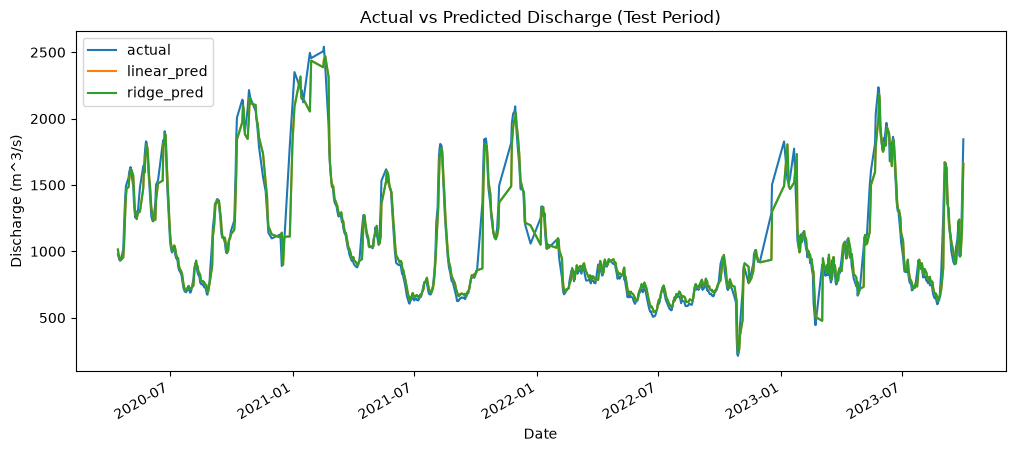

In [11]:
# Step 5: Build predictions table and visualize actual vs predicted
predictions = pd.DataFrame(
    {
        "actual": result["y_test"],
        "linear_pred": result["linear_pred"],
        "ridge_pred": result["ridge_pred"],
    },
    index=result["y_test"].index,
)

ax = predictions[["actual", "linear_pred", "ridge_pred"]].plot(
    figsize=(12, 5),
    title="Actual vs Predicted Discharge (Test Period)",
)
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (m^3/s)")

display(predictions.head())

## 7. Add Validation and Error Handling
Validation and guard clauses are handled in script modules used by this notebook.

## 8. Write In-Notebook Sanity Tests
Use lightweight assertions against outputs returned by `scripts.run_pipeline.run_station_experiment`.

In [10]:
# Sanity checks
assert len(result["feature_cols"]) > 0, "Feature list must not be empty"
assert predictions.shape[0] > 50, "Expected enough holdout rows for evaluation"
assert set(["actual", "linear_pred", "ridge_pred"]).issubset(predictions.columns)
assert result["metrics"]["linear_regression"]["rmse"] > 0
assert -1.0 <= result["metrics"]["linear_regression"]["r2"] <= 1.0

# Show top coefficients from script output
display(result["summary"])
display(result["feature_cols"][:10])

,model,rmse,mae,r2,best_alpha,cv_rmse
0,linear_regression,86.537888,55.227888,0.956394,NaN,NaN
1,ridge_regression,86.673773,55.346992,0.956256,1.0,138.340384


['lag_1',
 'lag_2',
 'lag_7',
 'lag_30',
 'roll_mean_7',
 'roll_std_7',
 'roll_mean_30',
 'roll_std_30',
 'month',
 'day_of_year']

In [ ]:
# Optional: run batch comparison directly in notebook using script function
comparison_df, failures_df = run_batch(
    csv_dir=cfg["csv_dir"],
    max_stations=cfg["max_stations"],
    test_fraction=cfg["test_fraction"],
)

comparison_output = cfg["results_dir"] / "station_comparison_notebook.csv"
failures_output = cfg["results_dir"] / "station_failures_notebook.csv"
comparison_df.to_csv(comparison_output, index=False)
failures_df.to_csv(failures_output, index=False)

print(f"Station comparison saved: {comparison_output}")
print(f"Failure log saved: {failures_output}")
comparison_df.head()

## How To Run The Full Process
1. Install dependencies from `requirements.txt`.
2. Run single-station pipeline script:
   - `python -m scripts.run_pipeline --station-file neodc/esacci/river_discharge/data/RD/RD-multi/v1.2/CSV/PO_BORGOFORTE_Q_Day.Cmd.csv`
3. Run multi-station comparison script (3-5 stations):
   - `python -m scripts.run_multi_station --max-stations 5`
4. Or run this notebook top-to-bottom.
5. Collect outputs from `results/` for report and slides.

## Limitations, Bias, and Ethics
- The target is derived using satellite-based and calibrated products; uncertainty may vary by basin and season.
- Some metadata fields include missing values (`nan`) and not all stations have equal temporal density.
- Linear models provide interpretability but may underfit strong nonlinear hydrological dynamics.
- Practical use should avoid overconfident operational decisions without domain validation.

## Technical Report + PPT Artifact Checklist
- Problem definition and objective: Notebook title + configuration sections.
- Dataset description and justification: this notebook intro + station metadata printout.
- Methodology and experiments: script-based pipeline function and model comparison metrics.
- Results and comparative analysis: metrics JSON/CSV and generated plots in `results/plots`.
- Limitations and lessons learned: section above.
- Conclusion/future work: summarize in report using coefficients and residual diagnostics.